In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import time
from multiprocessing import Pool
from tqdm.auto import tqdm
import re
from copy import deepcopy

import numpy as np
from scipy import integrate
from matplotlib import pyplot as plt

import noctiluca as nl
import bayesmsd

/home/sgh/gitlibs/chromatin_dynamics/.venv_SD_py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib as mpl
import matplotlib.colors as mplc

mpl.rcParams['figure.dpi'] = 300

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "DejaVu Sans"
mpl.rcParams['font.size'] = 6

mpl.rcParams['xtick.major.size'] = 2
mpl.rcParams['xtick.major.pad'] = 1
mpl.rcParams['ytick.major.size'] = 2
mpl.rcParams['ytick.major.pad'] = 1
mpl.rcParams['xtick.minor.size'] = 1
mpl.rcParams['xtick.minor.pad'] = 0.5
mpl.rcParams['ytick.minor.size'] = 1
mpl.rcParams['ytick.minor.pad'] = 0.5
mpl.rcParams['axes.labelpad'] = 1
mpl.rcParams['axes.titlepad'] = 3
mpl.rcParams['axes.titlelocation'] = 'left'
mpl.rcParams['legend.handletextpad'] = 0.4
mpl.rcParams['legend.columnspacing'] = 1.0
mpl.rcParams['legend.frameon'] = False

mpl.rcParams['figure.subplot.top'] = 0.9
mpl.rcParams['figure.subplot.bottom'] = 0.2
mpl.rcParams['figure.subplot.left'] = 0.1
mpl.rcParams['figure.subplot.right'] = 0.98

In [3]:
# data = nl.io.load.hdf5('../data/20250411_chromatin_dynamics_all_data.h5', '/data')
data = nl.io.load.hdf5('/data/sgh/science/2024_minflux/20260106_chromatin_dynamics_all_data.h5', '/data')
len(data)

76429

In [4]:
conditions = [
    ['H2B', 'minflux', 'mESC', 'ctrl'],
#     ['H2B', 'minflux', 'mESC', 'DRB'],
#     ['H2B', 'minflux', 'mESC', 'TSA'],
#     ['H2B', 'minflux', 'mESC', 'ICRF'],
    ['H2B', 'minflux', 'U2OS', 'ctrl'],
#     ['H2B', 'minflux', 'U2OS', 'DRB'],
#     ['H2B', 'minflux', 'U2OS', 'TSA'],
#     ['H2B', 'minflux', 'U2OS', 'ICRF'],
    ['H2B', 'minflux', 'MEF', 'ctrl'],
    ['H2B', 'minflux', 'RPE', 'ctrl'],
    ['H2B', 'minflux', 'RH30', 'ctrl'],
    ['H2B', 'SPT-100ms', 'mESC', 'ctrl'],
#     ['H2B', 'SPT-100ms', 'mESC', 'DRB'],
#     ['H2B', 'SPT-100ms', 'mESC', 'TSA'],
#     ['H2B', 'SPT-100ms', 'mESC', 'ICRF'],
    ['H2B', 'SPT-100ms', 'U2OS', 'ctrl'],
#     ['H2B', 'SPT-100ms', 'U2OS', 'DRB'],
#     ['H2B', 'SPT-100ms', 'U2OS', 'TSA'],
#     ['H2B', 'SPT-100ms', 'U2OS', 'ICRF'],
    ['H2B', 'SPT-100ms', 'MEF', 'ctrl'],
    ['H2B', 'SPT-100ms', 'RPE', 'ctrl'],
    ['H2B', 'SPT-100ms', 'RH30', 'ctrl'],
    ['H2B', 'SPT-2s', 'mESC', 'ctrl'],
#     ['H2B', 'SPT-2s', 'mESC', 'DRB'],
#     ['H2B', 'SPT-2s', 'mESC', 'TSA'],
#     ['H2B', 'SPT-2s', 'mESC', 'ICRF'],
    ['H2B', 'SPT-2s', 'U2OS', 'ctrl'],
#     ['H2B', 'SPT-2s', 'U2OS', 'DRB'],
#     ['H2B', 'SPT-2s', 'U2OS', 'TSA'],
#     ['H2B', 'SPT-2s', 'U2OS', 'ICRF'],
    ['H2B', 'SPT-2s', 'MEF', 'ctrl'],
    ['H2B', 'SPT-2s', 'RPE', 'ctrl'],
    ['H2B', 'SPT-2s', 'RH30', 'ctrl'],
#     ['array', 'minflux', 'C36'],
#     ['array', 'minflux', 'ΔRAD21 (inactive)'],
#     ['array', 'minflux', 'ΔRAD21 (active)'],
#     ['array', 'SPT-100ms', 'C36'],
#     ['array', 'SPT-100ms', 'ΔRAD21 (inactive)'],
#     ['array', 'SPT-100ms', 'ΔRAD21 (active)'],
#     ['array', 'SPT-2s', 'C36'],
#     ['array', 'SPT-2s', 'ΔRAD21 (inactive)'],
#     ['array', 'SPT-2s', 'ΔRAD21 (active)'],
#     ['array', 'SRLCI', 'C36'],
#     ['array', 'SRLCI', 'ΔRAD21 (inactive)'],
#     ['array', 'SRLCI', 'ΔRAD21 (active)'],
]

  0%|                                                                                                        | 0/15 [00:00<?, ?it/s]

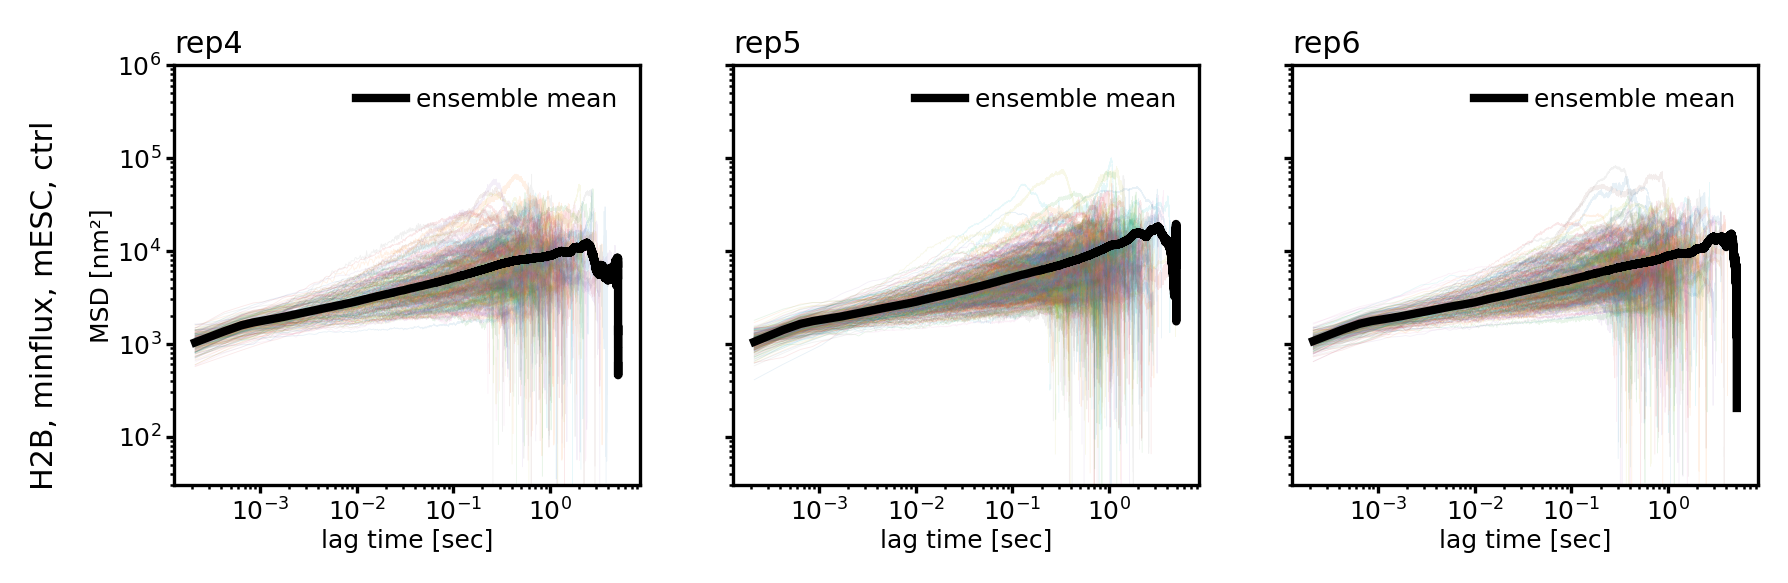

  7%|██████▍                                                                                         | 1/15 [00:10<02:30, 10.75s/it]

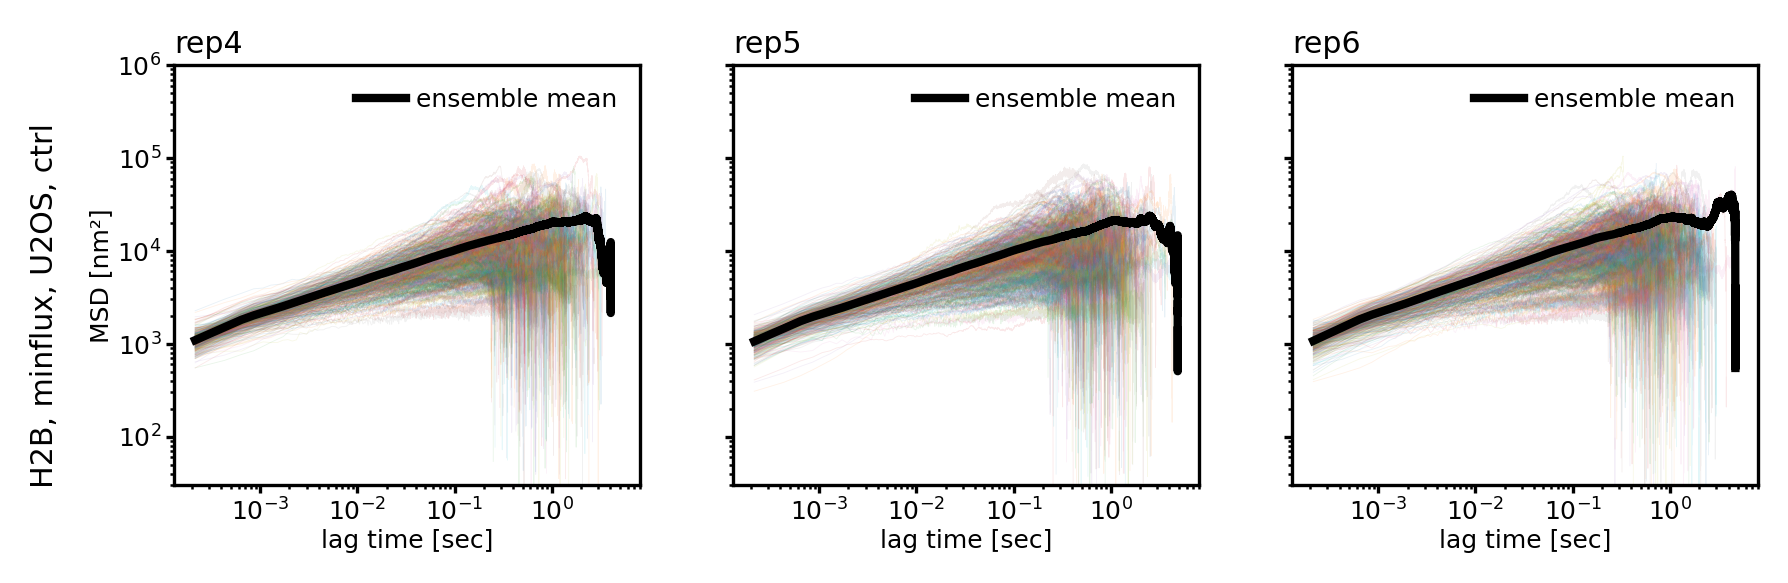

 13%|████████████▊                                                                                   | 2/15 [00:25<02:47, 12.86s/it]

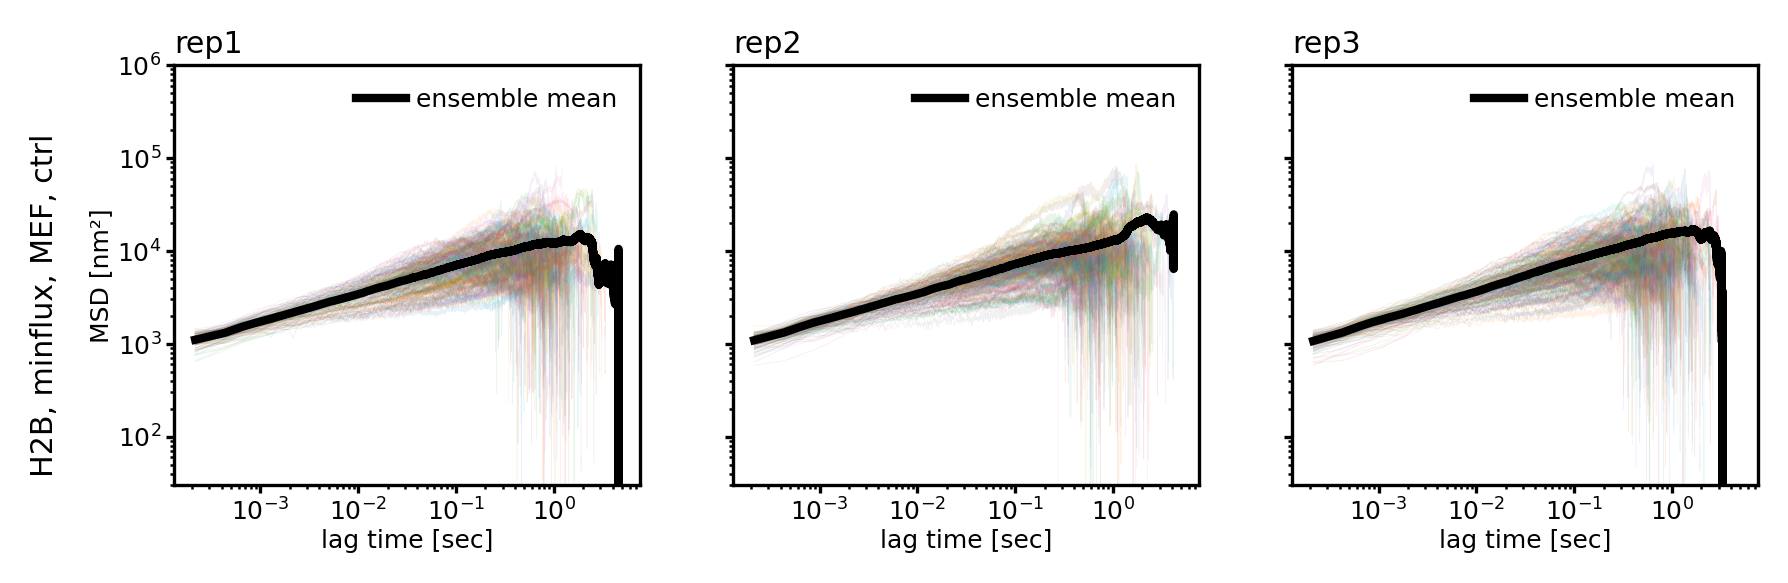

 20%|███████████████████▏                                                                            | 3/15 [00:32<02:06, 10.57s/it]

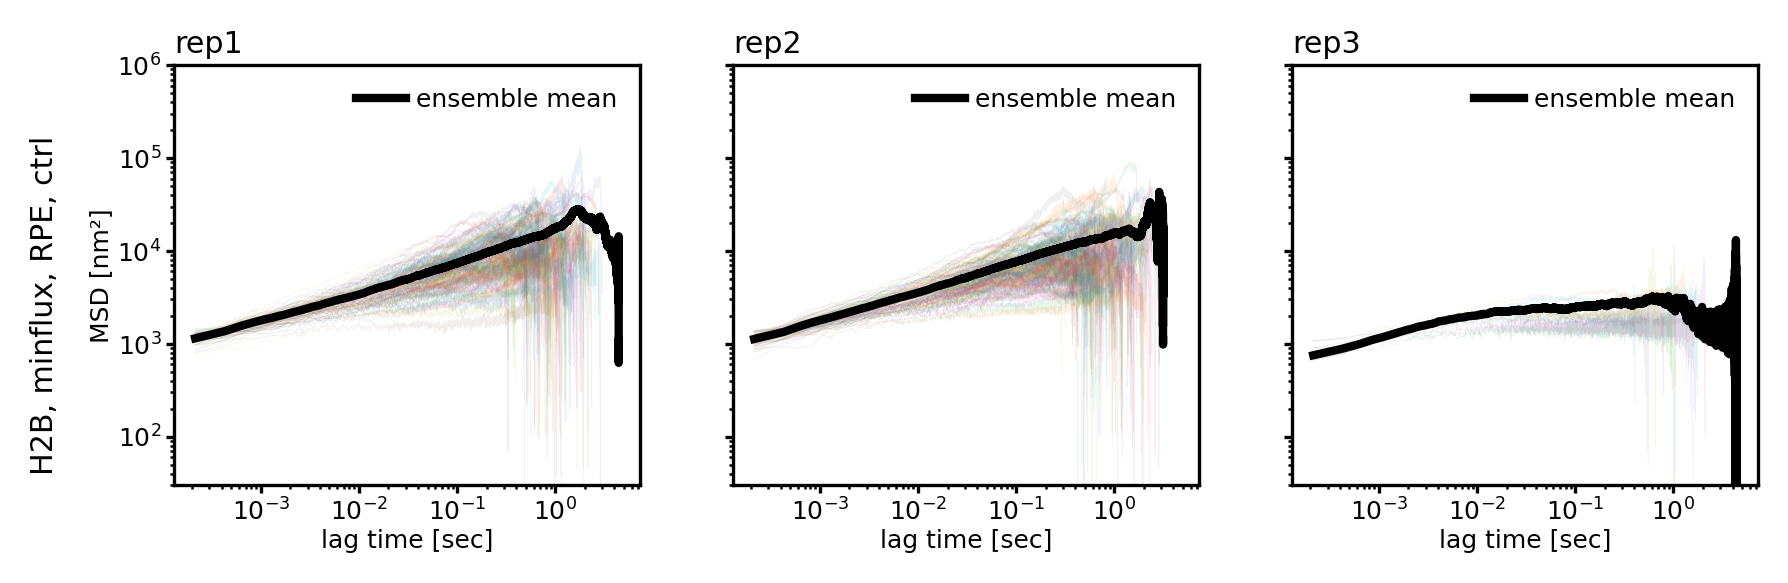

 27%|█████████████████████████▌                                                                      | 4/15 [00:37<01:28,  8.02s/it]

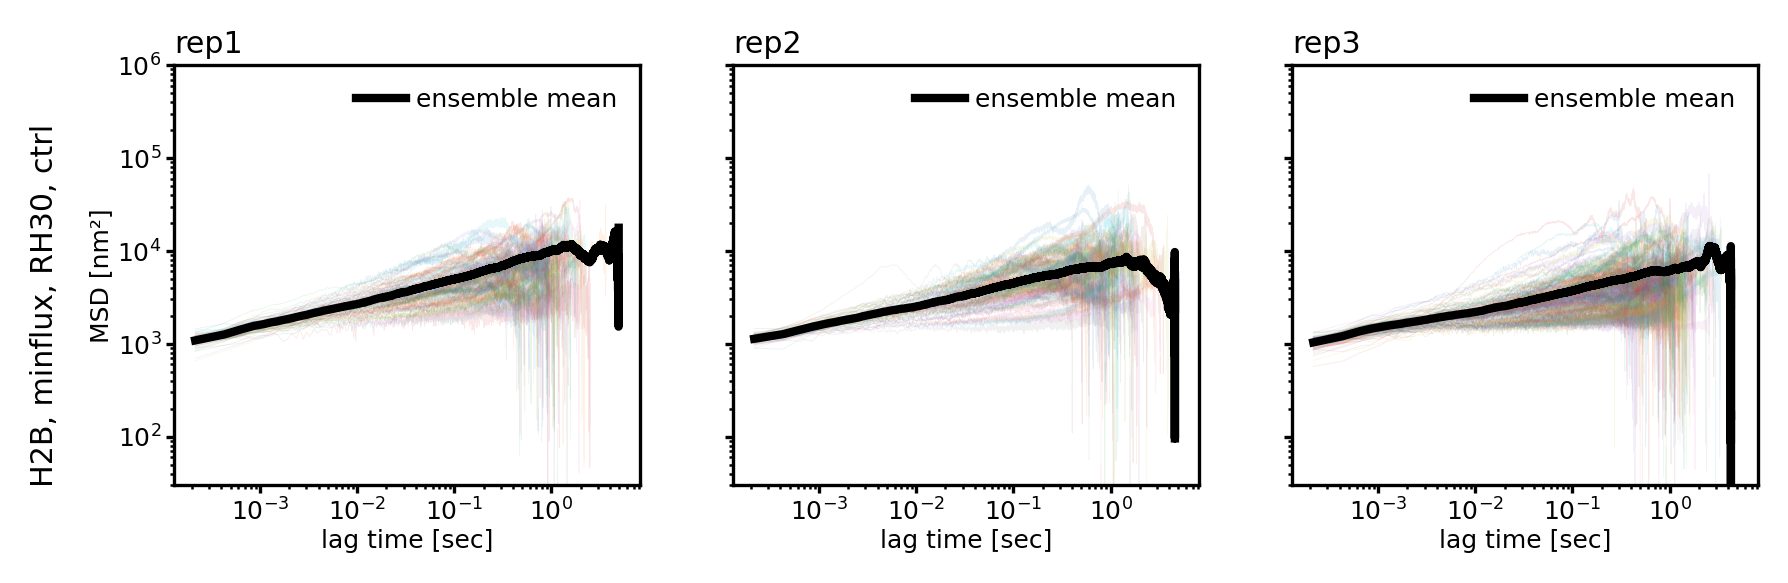

 33%|████████████████████████████████                                                                | 5/15 [00:42<01:10,  7.08s/it]

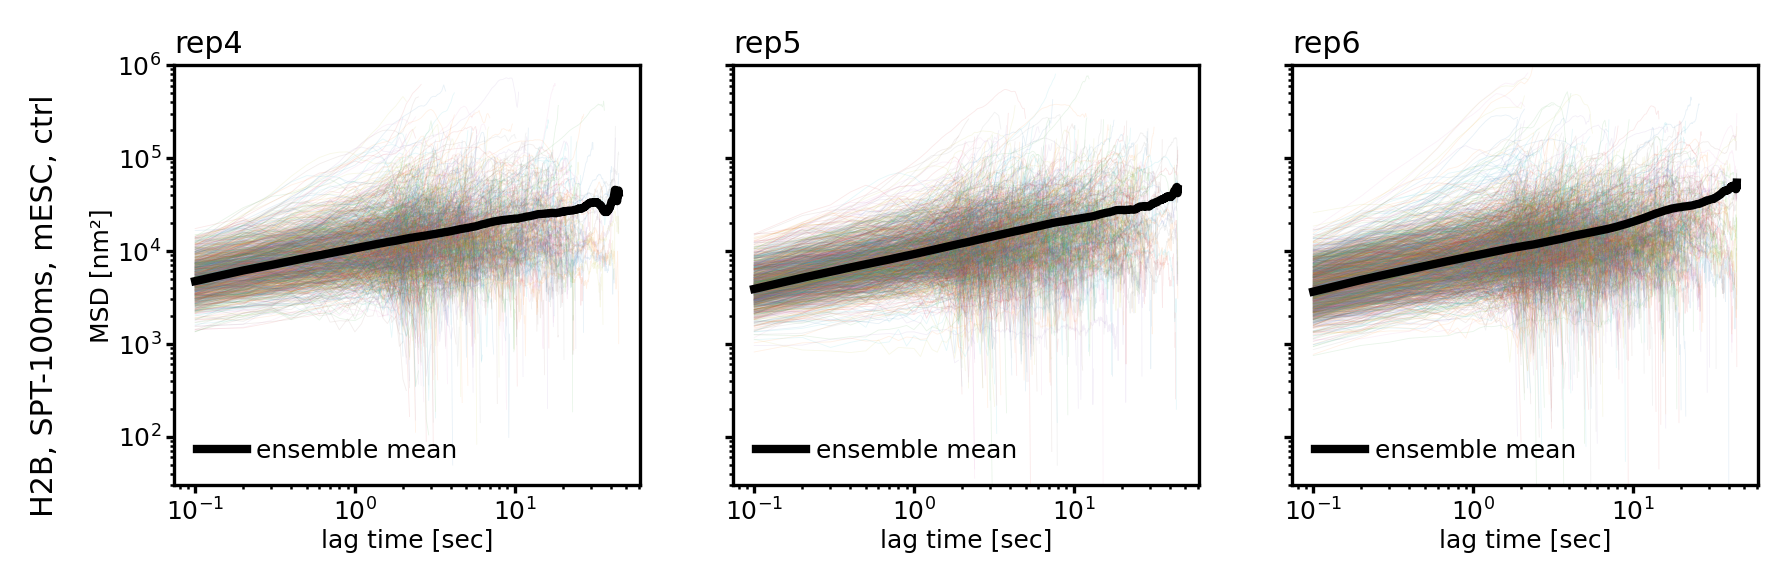

 40%|██████████████████████████████████████▍                                                         | 6/15 [01:00<01:36, 10.77s/it]

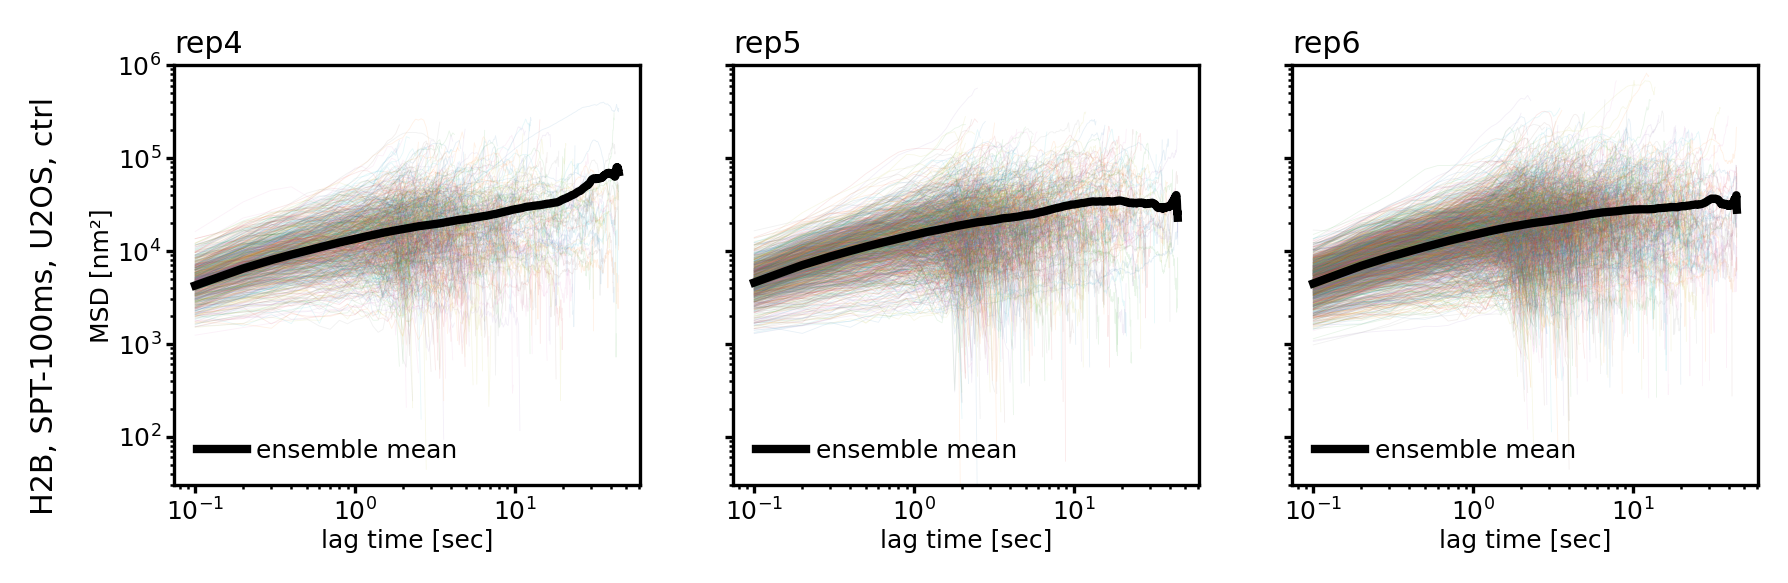

 47%|████████████████████████████████████████████▊                                                   | 7/15 [01:16<01:40, 12.60s/it]

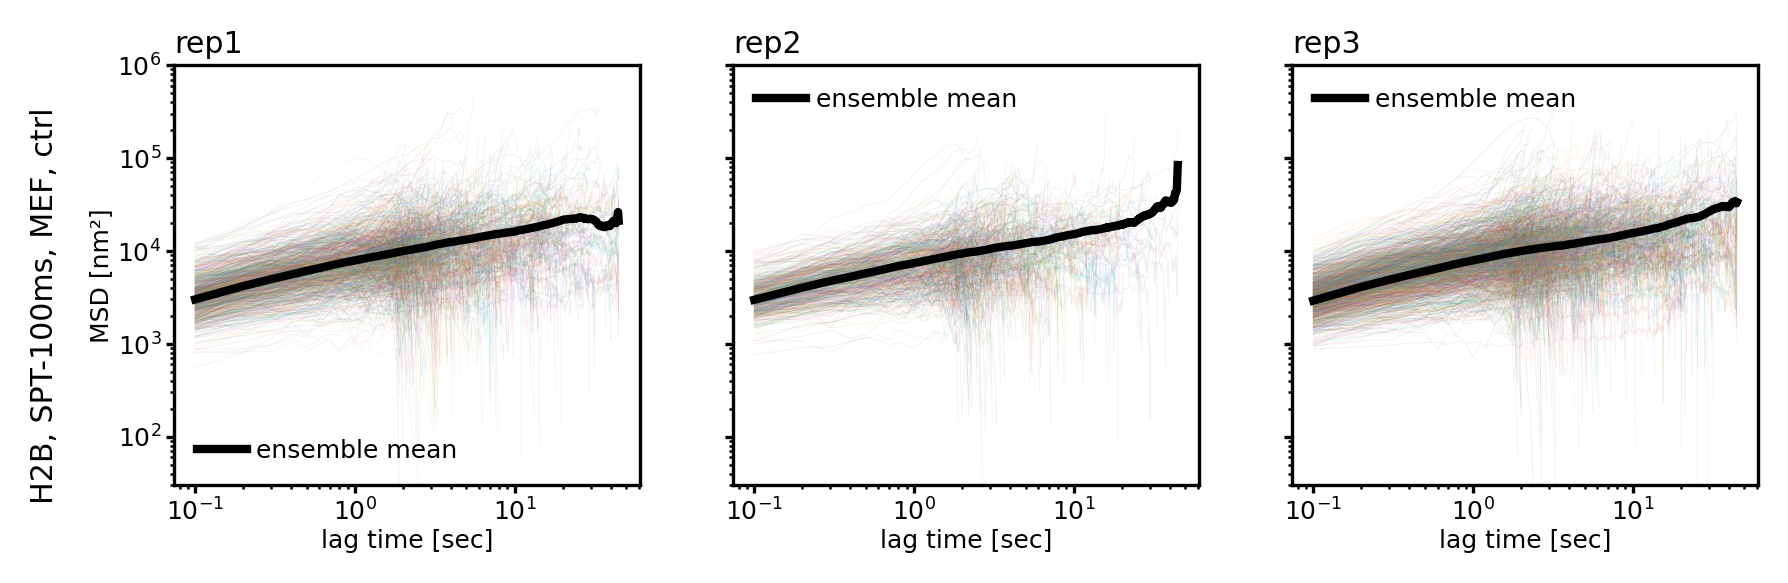

 53%|███████████████████████████████████████████████████▏                                            | 8/15 [01:27<01:23, 11.90s/it]

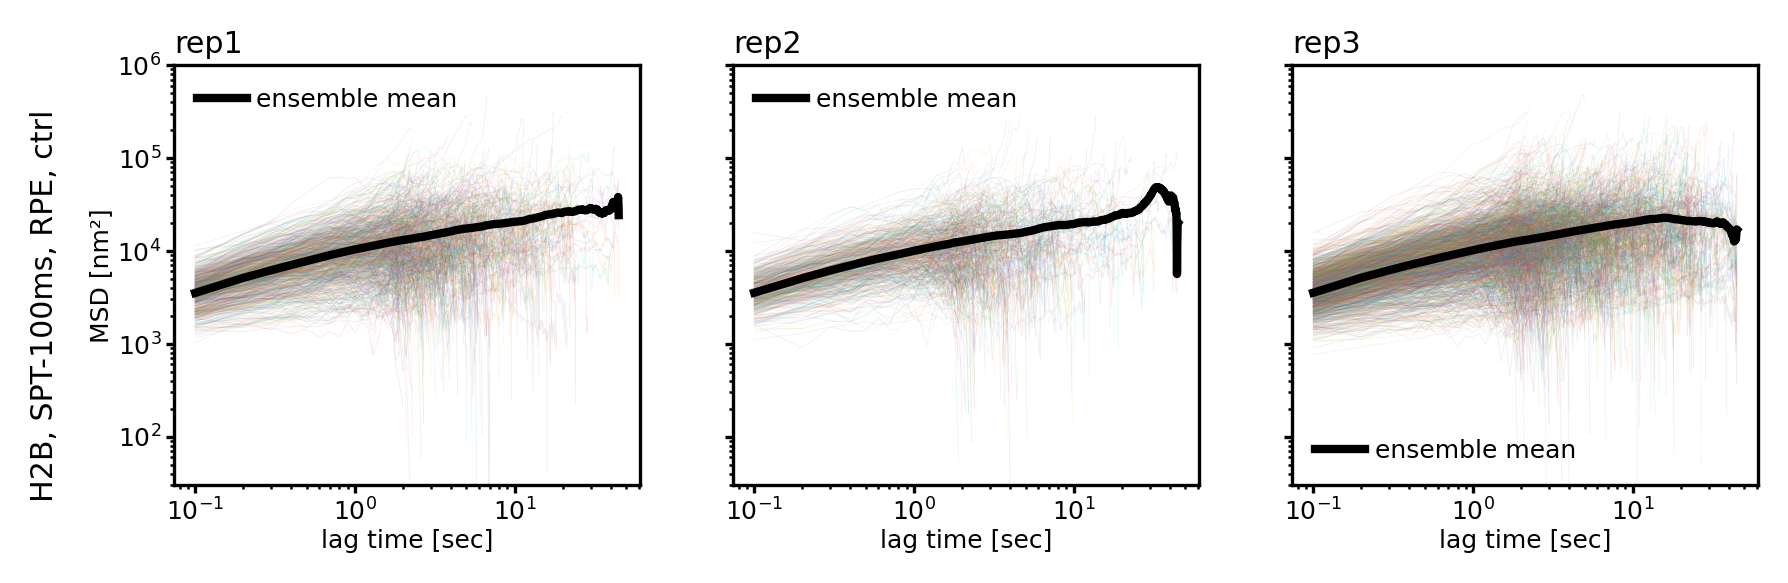

 60%|█████████████████████████████████████████████████████████▌                                      | 9/15 [01:39<01:11, 11.93s/it]

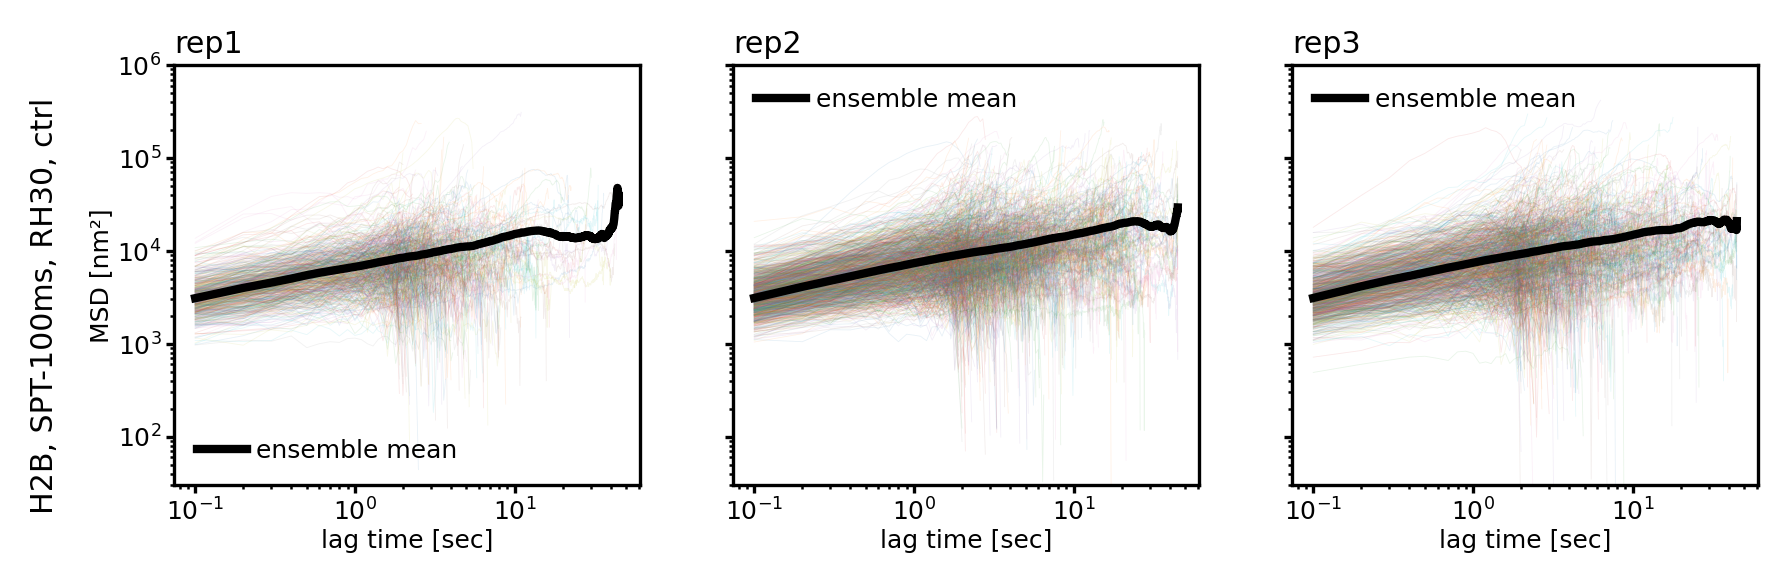

 67%|███████████████████████████████████████████████████████████████▎                               | 10/15 [01:52<01:01, 12.22s/it]

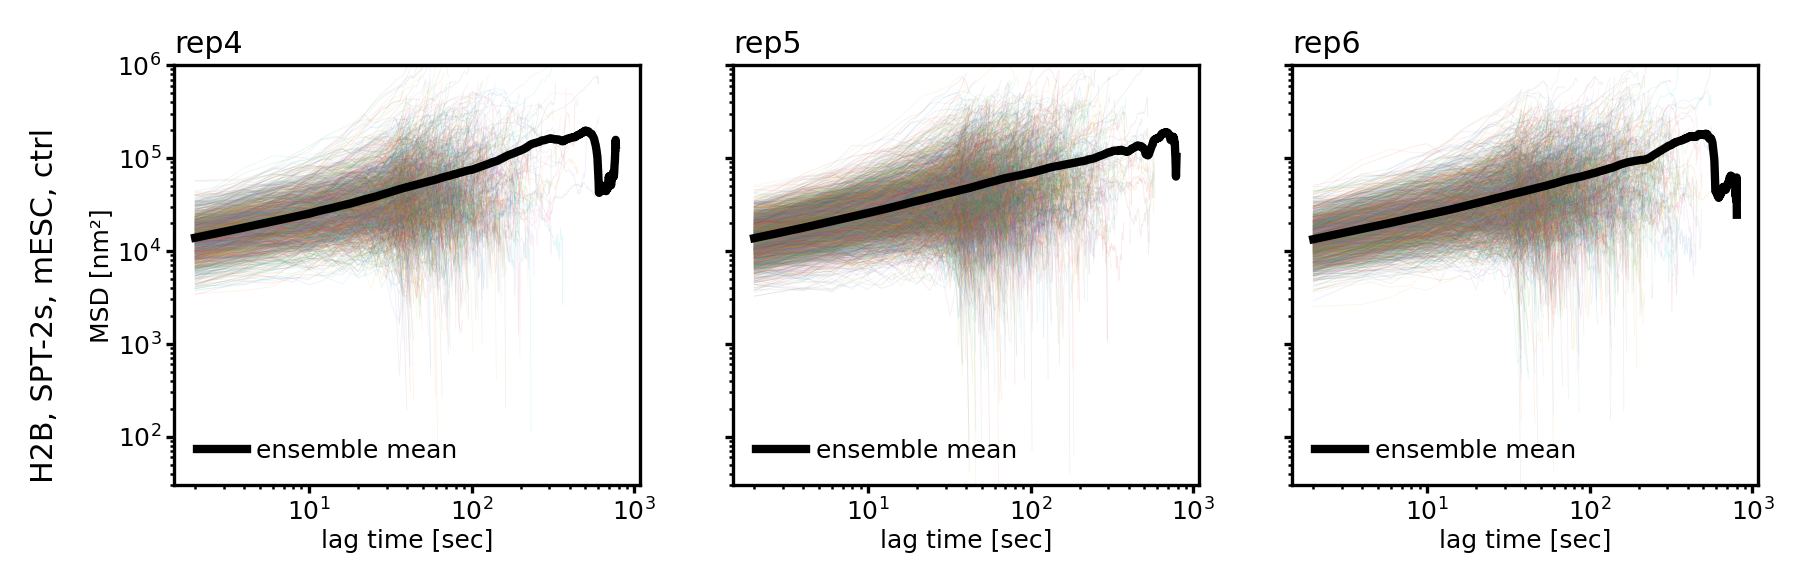

 73%|█████████████████████████████████████████████████████████████████████▋                         | 11/15 [02:12<00:59, 14.88s/it]

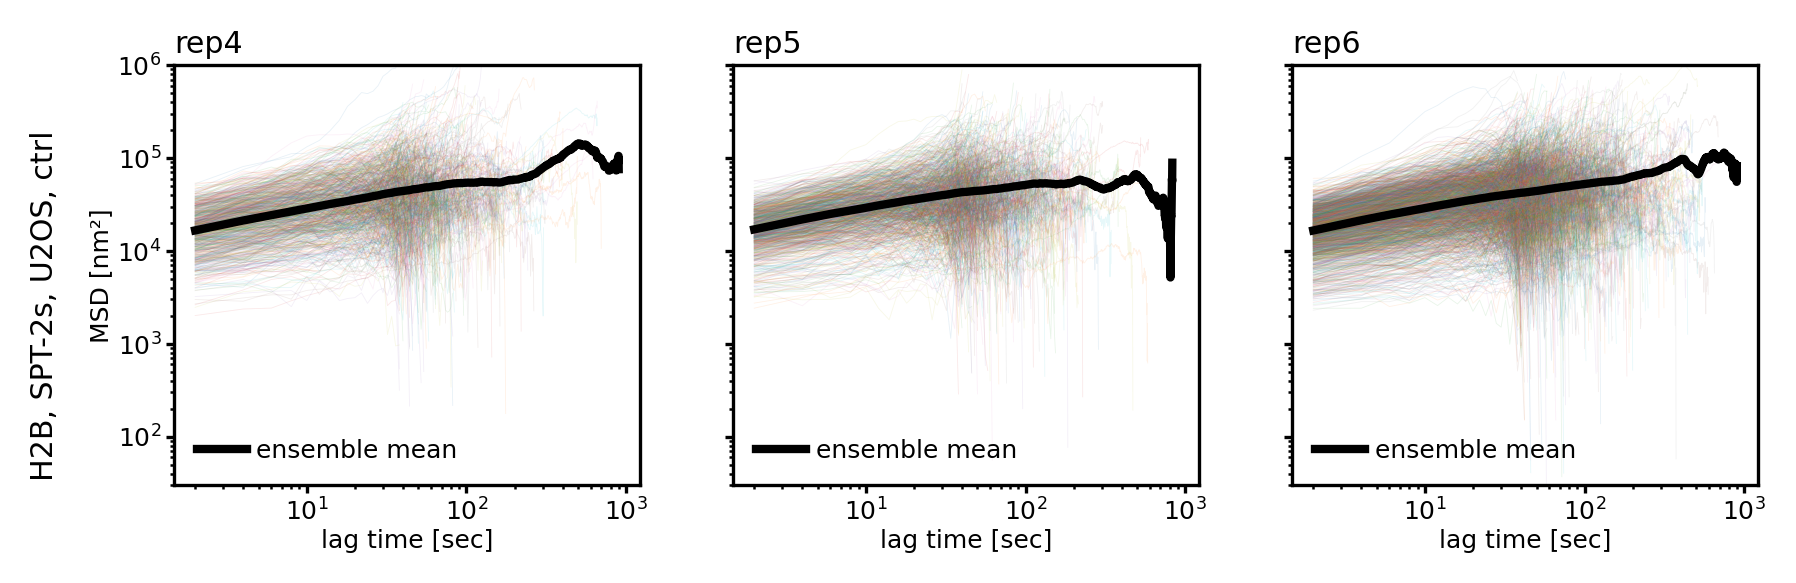

 80%|████████████████████████████████████████████████████████████████████████████                   | 12/15 [02:26<00:43, 14.61s/it]

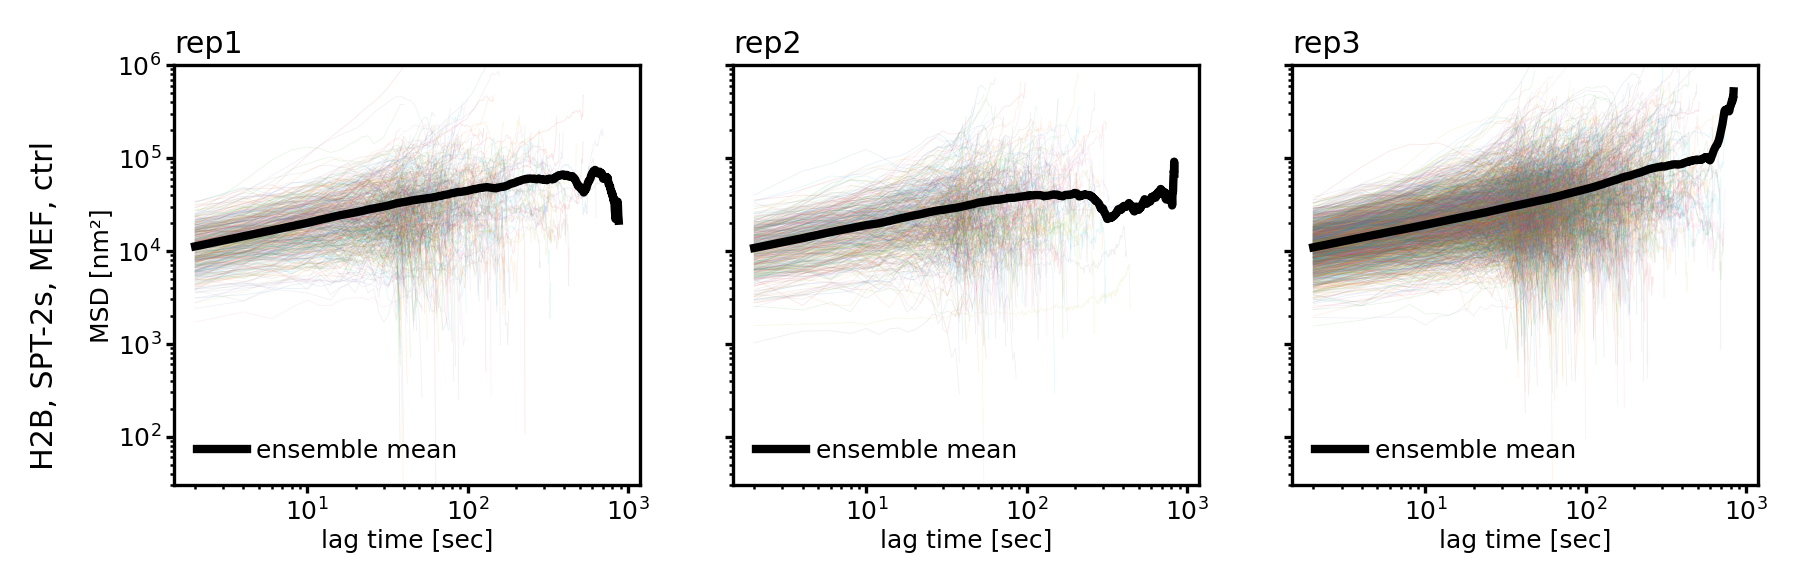

 87%|██████████████████████████████████████████████████████████████████████████████████▎            | 13/15 [02:38<00:27, 13.83s/it]

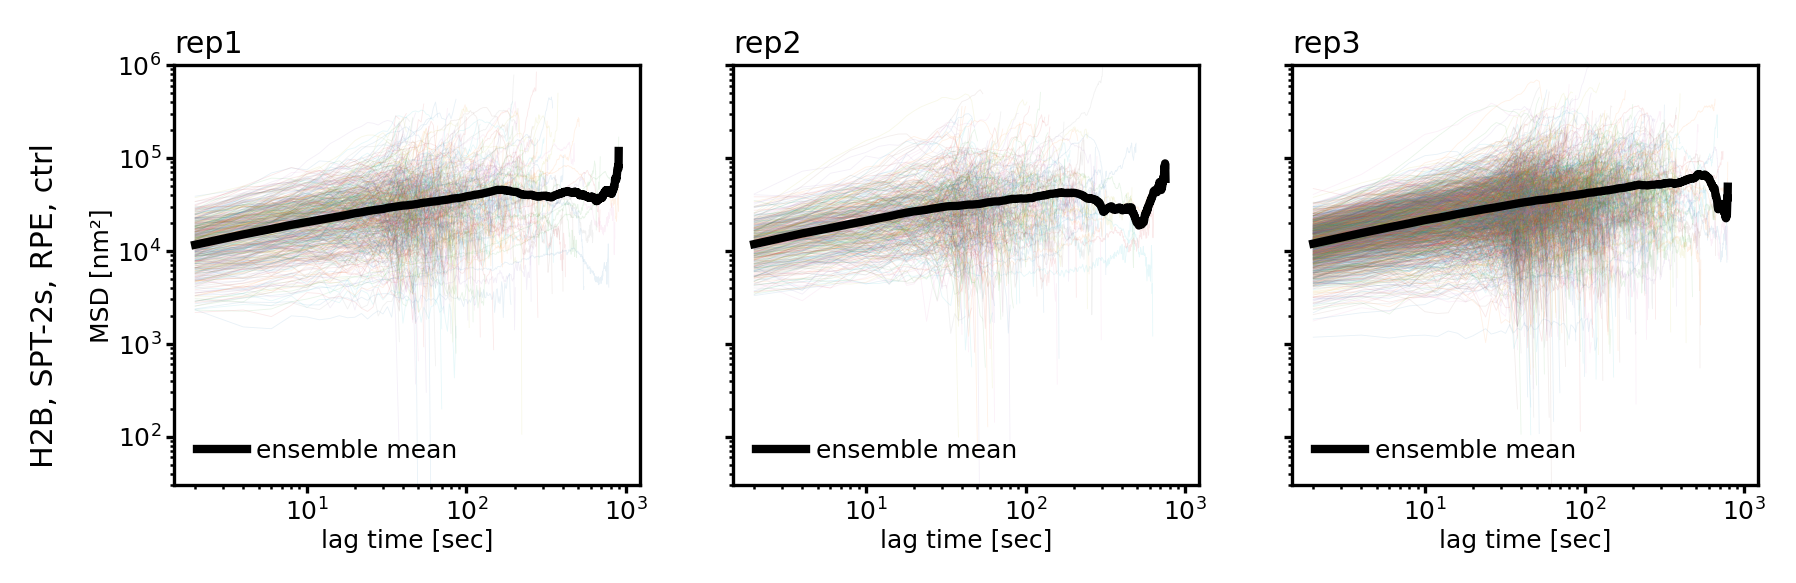

 93%|████████████████████████████████████████████████████████████████████████████████████████▋      | 14/15 [02:49<00:12, 12.92s/it]

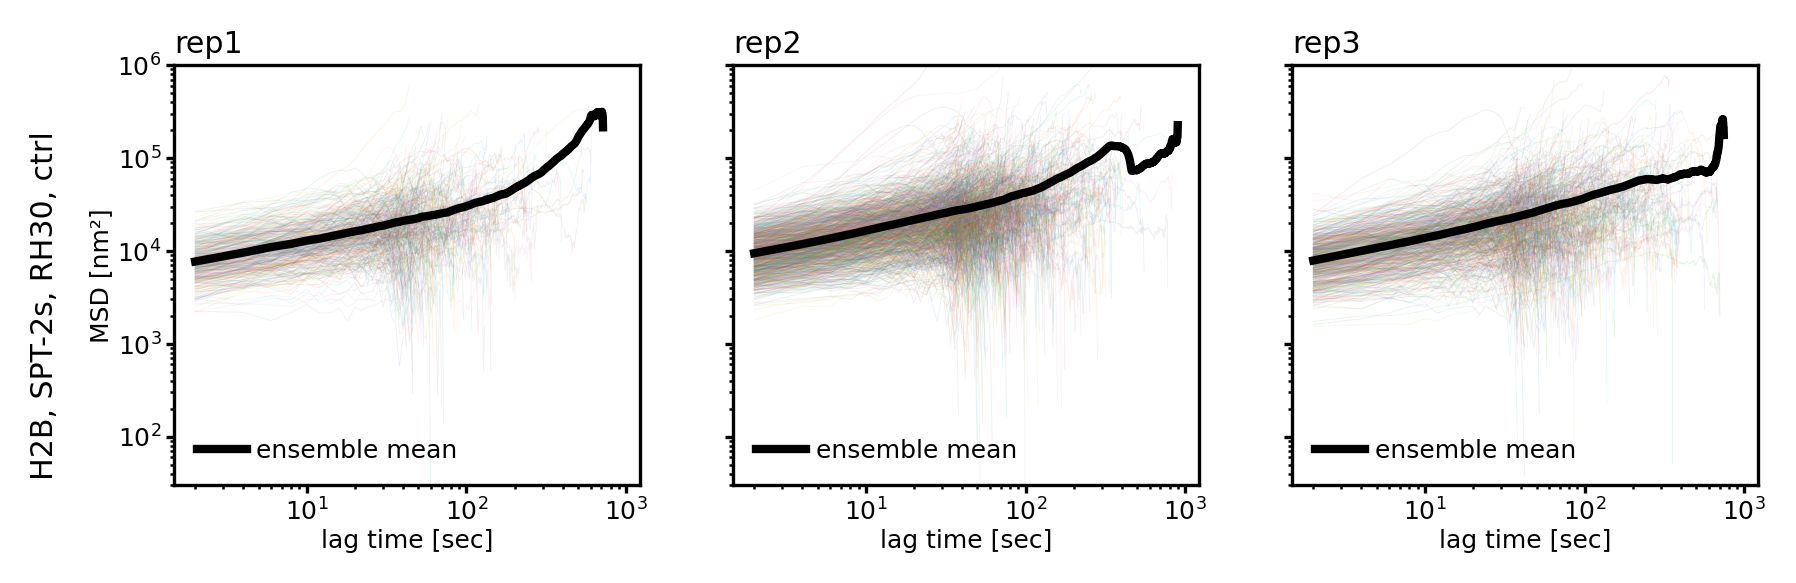

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [02:58<00:00, 11.92s/it]


In [29]:
for cond in tqdm(conditions):
    data.makeSelection(cond, logic=all)
    is_rep456 = False
    if len(set(cond) & {'mESC', 'U2OS'}) > 0:
        def sel_revision_files(_, tags):
            import re
            filetag = [tag for tag in tags if tag.startswith('file=')][0]
            m = re.search(r'Tracks_(\d{8})_.*\.xml$|/(\d{6})-(\d{6})_minflux\.npy$', tag)
            if m is None:
                raise RuntimeError
            elif m[1] is not None:
                date = m[1]
            elif m[2] is not None:
                date = '20'+m[2]
            else:
                raise RuntimeError
            
            return date > '20251001' # lexicographical comparison works fine for YYYYMMDD dates
        data.refineSelection(sel_revision_files)
        is_rep456 = True
    
    sel = data.saveSelection()
        
    reptags = ['rep1', 'rep2', 'rep3']
    dt = data[0].meta['Δt']
    
    fig, axs = plt.subplots(1, len(reptags), figsize=[6, 2], sharex=True, sharey=True)
    
    for ax, reptag in zip(axs, reptags):
        data.restoreSelection(sel)
        data.refineSelection(reptag)
        if len(data) == 0:
            ax.remove()
            continue
        
        fac_1p2D_nm2 = 1e18 if 'minflux' in cond else 1e6 # nm²
        if 'minflux' not in cond:
            fac_1p2D_nm2 /= 2                             # 2-loc --> 1-loc
        
        alpha = 0.1
        if 'array' in cond and 'SRLCI' not in cond:
            alpha = 0.5
        
        # for Fbn2 steady state separations
        trans_ax_dat = mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData)
        
        for traj in data:
            msd = nl.analysis.MSD(traj) * fac_1p2D_nm2
            h = ax.plot(dt*np.arange(1, len(msd)), msd[1:],
                        alpha=alpha, linewidth=0.2,
                        rasterized=True,
                       )
            if 'SRLCI' in cond:
                J = np.nanmean(traj.abs()[:][:, 0]**2) * fac_1p2D_nm2
                ax.hlines(2*J, 0.98, 1.02,
                          alpha=h[0].get_alpha(),
                          linewidth=h[0].get_linewidth(),
                          color=h[0].get_color(),
                          zorder=20, clip_on=False,
                          transform=trans_ax_dat,
                          rasterized=True,
                         )
                
        msd = nl.analysis.MSD(data) * fac_1p2D_nm2
        h = ax.plot(dt*np.arange(1, len(msd)), msd[1:],
                    linewidth=2,
                    color='k',
                    label='ensemble mean',
                   )
        if 'SRLCI' in cond:
            J = np.nanmean(np.concatenate([traj.abs()[:][:, 0] for traj in data])**2) * fac_1p2D_nm2
            ax.hlines(2*J, 0.98, 1.02,
                      alpha=h[0].get_alpha(),
                      linewidth=h[0].get_linewidth(),
                      color=h[0].get_color(),
                      zorder=20, clip_on=False,
                      transform=trans_ax_dat,
                     )
            ax.text(1.03, 2*J, r'$2\langle R^2\rangle$',
                    rotation=90, ha='left', va='center',
                    clip_on=False,
                    transform=trans_ax_dat,
                   )
            ax.set_xlim([13, 1.1e4]) # need to do by hand, because hlines screws up autoscaling
        
        ax.legend()
        ax.set_xlabel('lag time [sec]')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(reptag if not is_rep456 else reptag[:-1]+str(int(reptag[-1])+3))
    
    ax = axs[0]
    ax.set_ylim([3e1, 1e6])
    ax.set_ylabel('MSD [nm²]')
    fig.supylabel(', '.join(cond), x=0.02)
    
    filename = '_'.join(cond) + '.pdf'
    filename = '-'.join(filename.split(' '))
    char_blacklist = set('Δ()')
    filename = ''.join([c for c in filename if c not in char_blacklist])
    plt.savefig('/data/sgh/science/2024_minflux/plots/single-traj_MSDs/'+filename, dpi=300)
    
    plt.show()